# WASD Imitation Learning
WASD Super Sequence (SS): Game wherein you enter a sequence of letters instead of just 1 letter.

In this notebook, I explore the concept of Imitation Learning/Behaviour Cloning by playing a game I built myself named WASD. I first play the game myself to gather "expert data" which can then be used to train a model to play the game like how I would.

Note: IL part worked, however, when trying to continue the model using RL it only gets worse and I don't know why. This is most likely because I forgot to implement the reward into the learning proces...

### Collecting Data
This block allows the user to play the game and gather data to train the model

In [5]:
import gymnasium as gym
import numpy as np
import pickle
import keyboard  # Import the keyboard library
from WASDEnv import WinFormsGameEnv
from helper import alt_tab
import time

# Initialize environment
env = WinFormsGameEnv(action_pipeline=False)
obs, _ = env.reset()

# Data storage
obs_list = []
action_list = []

# Limit the data collection to 50 states
max_states = 50
state_counter = 0

def get_user_action():
    # Use the keyboard library to check which key is pressed
    if keyboard.is_pressed('w'):  # Move up
        return 0
    elif keyboard.is_pressed('a'):  # Move left
        return 1
    elif keyboard.is_pressed('s'):  # Move down
        return 2
    elif keyboard.is_pressed('d'):  # Move right
        return 3
    else:
        return None  # No action pressed

while state_counter < max_states:
    user_action = get_user_action() # get user action
    # game processes this action
    if user_action is not None:
        obs_list.append(obs)
        action_list.append(user_action)
        state_counter += 1

        # Step in the environment
        time.sleep(.005) # give env time to process the input
        obs, reward, terminated, truncated, _ = env.step(user_action)
        done = terminated or truncated
        if done:
            obs, _ = env.reset()

        # Wait until all WASD keys are released before continuing
        while any(keyboard.is_pressed(k) for k in ['w', 'a', 's', 'd']):
            time.sleep(0.01)  # small delay to prevent busy waiting


# Save data
with open("WASD_demos.pkl", "wb") as f:
    pickle.dump((obs_list, action_list), f)

print("🎉 Saved", len(obs_list), "frames of expert data!")


alt_tab()


KeyboardInterrupt: 

### Concatenate Data
Code to concatenate multiple expert runs (if there are multiple)

In [8]:
import pickle

# File paths for each of your individual demo files
file_paths = [
    "WASD_demos_1.pkl",
    "WASD_demos_2.pkl",
    "WASD_demos_3.pkl",
    "WASD_demos_4.pkl",
    "WASD_demos_5.pkl",
]

# Initialize empty lists to hold the concatenated observations and actions
all_obs = []
all_actions = []

# Load each of the .pkl files and append the data
for file_path in file_paths:
    with open(file_path, 'rb') as f:
        obs_list, action_list = pickle.load(f)
        all_obs.extend(obs_list)  # Concatenate observations
        all_actions.extend(action_list)  # Concatenate actions

# Save the concatenated data to a new .pkl file
with open("WASD_demos_combined.pkl", 'wb') as f:
    pickle.dump((all_obs, all_actions), f)

print(f"🎉 Concatenated and saved {len(all_obs)} frames of expert data!")


🎉 Concatenated and saved 250 frames of expert data!


## Data Insights
Inspecting how much data there is for each state. There are only 4 different states, meaning a low amount of data is sufficient for this project. Important is that there are at least a few states per letter, so that the model won't think the score and letter are connected.

In [2]:
import numpy as np
import pickle

with open("WASD_demos_combined.pkl", "rb") as f:
    obs_list, action_list = pickle.load(f)

actions = np.array(action_list)
print("Action 0 count:", np.sum(actions == 0))
print("Action 1 count:", np.sum(actions == 1))
print("Action 2 count:", np.sum(actions == 2))
print("Action 3 count:", np.sum(actions == 3))


Action 0 count: 75
Action 1 count: 57
Action 2 count: 61
Action 3 count: 57


## Train model on expert data

In [6]:
import torch
import gymnasium as gym
import numpy as np
import pickle
import keyboard  # Import the keyboard library
from WASDEnv import WinFormsGameEnv
from helper import alt_tab
import time 
from torch.utils.data import TensorDataset, DataLoader
from DQNCNN import DQNCNN
import torch
import torch.nn as nn
import torch.optim as optim


# Convert obs_list to numpy array
obs_array = np.array(obs_list)  # Shape: (batch_size, 84, 84)

# Add a channel dimension (1 channel for grayscale images)
obs_array = obs_array[:, np.newaxis, :, :]  # New shape: (batch_size, 1, 84, 84)

# Convert to tensors
obs_tensor = torch.FloatTensor(obs_array)  # Shape: (batch_size, 1, 84, 84)
actions_tensor = torch.LongTensor(action_list)

# Create DataLoader
dataset = TensorDataset(obs_tensor, actions_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Instantiate model with action_size and stack_size = 1
bc_model = DQNCNN(action_size=4)  # Make sure action_size matches your setup
# bc_model.load_state_dict(torch.load("bc_model.pth"))
optimizer = optim.Adam(bc_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(500):
    for batch_obs, batch_act in dataloader:
        print("Input shape to model:", batch_obs.shape)  # Should be (batch_size, 1, 84, 84)
        
        batch_obs = batch_obs.squeeze(1)
        print("Input shape to model:", batch_obs.shape)  # Should be (batch_size, 1, 84, 84)
        
        logits = bc_model(batch_obs)
        loss = criterion(logits, batch_act)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1} | Loss: {loss.item():.4f}")

# Save the model
torch.save(bc_model.state_dict(), "bc_model.pth")


Input shape to model: torch.Size([1, 1, 1, 3, 48, 48])
Input shape to model: torch.Size([1, 1, 3, 48, 48])


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [1, 1, 3, 48, 48]

## Verify the data
Below are samples to confirm that the data is labeled correctly.


C:\Users\Kaan\AppData\Local\Temp\ipykernel_9952\2779101124.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bc_model.load_state_dict(torch.load("bc_model.pth"))


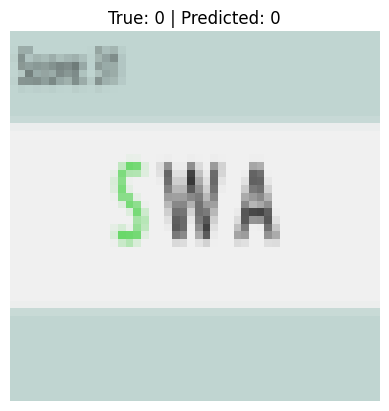

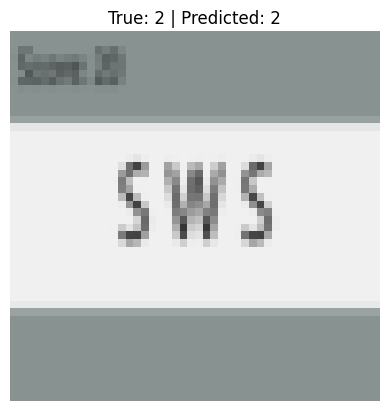

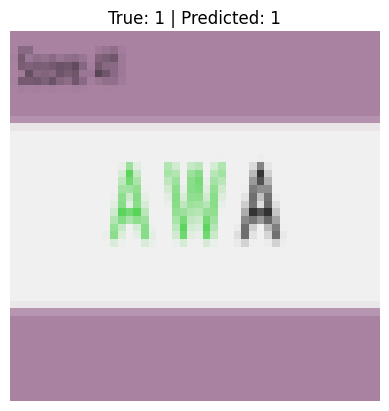

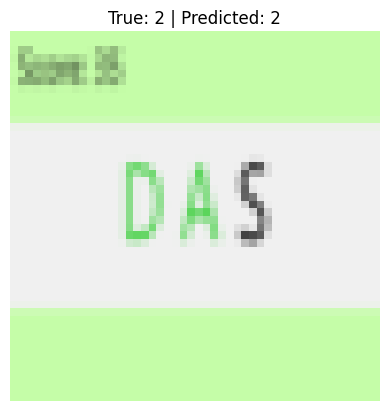

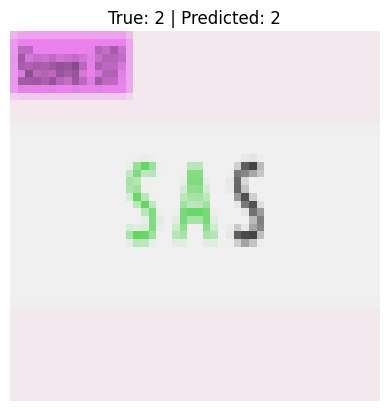

In [11]:
import torch
import matplotlib.pyplot as plt
import random
import pickle
import numpy as np
from DQNCNN import DQNCNN

# === Load data ===
with open("WASD_demos_combined.pkl", "rb") as f:
    obs_list, action_list = pickle.load(f)

# Preprocess
obs_array = np.array(obs_list)  # (N, 84, 84)
obs_array = obs_array[:, np.newaxis, :, :]  # (N, 1, 84, 84)
obs_tensor = torch.FloatTensor(obs_array)
actions_tensor = torch.LongTensor(action_list)

# === Load trained model ===
bc_model = DQNCNN(action_size=4)
bc_model.load_state_dict(torch.load("bc_model.pth"))
bc_model.eval()

# === Visualize predictions on 5 random samples ===
sample_indices = random.sample(range(len(obs_tensor)), 5)

for idx in sample_indices:
    obs_sample = obs_tensor[idx].unsqueeze(0)  # (1, 1, 84, 84)
    true_action = actions_tensor[idx].item()

    with torch.no_grad():
        obs_sample = obs_sample.squeeze(1)
        logits = bc_model(obs_sample)
        pred_action = torch.argmax(logits, dim=1).item()

    # Plot image
    image = obs_sample.squeeze(0).permute(1, 2, 0).cpu().numpy()
    image = (image * 255).clip(0, 255).astype(np.uint8)  # scale and clip
    plt.imshow(image)


    plt.title(f"True: {true_action} | Predicted: {pred_action}")
    plt.axis('off')
    plt.show()


## Testing the model
Below the code to test the model

In [7]:
import torch
import numpy as np
import pickle
from DQNCNN import DQNCNN
from WASDEnv import WinFormsGameEnv  # or your custom gym env

# Load trained model
model = DQNCNN(action_size=4)
model.load_state_dict(torch.load("models/bc_model_5000.pth"))
model.eval()

# Create environment
env = WinFormsGameEnv()
obs, _ = env.reset()

epochs = 100
scores = []
for epoch in range(epochs):
    score = 0
    done = False
    while not done and score < 100:
        # Preprocess observation: (84, 84) -> (1, 1, 84, 84)
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0).unsqueeze(0)  # Add batch and channel dims

        # Get model prediction
        with torch.no_grad():
            obs_tensor = obs_tensor.squeeze(1)
            logits = model(obs_tensor)
            action = torch.argmax(logits, dim=1).item()

        # Take action in env
        time.sleep(.00002)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        score+=1
    scores.append(score)
    

env.close()
print(scores)


C:\Users\Kaan\AppData\Local\Temp\ipykernel_10316\678751890.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/bc_model_5000.pth"))


[2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2]


# Gradcam to inspect the results
The gradcam shows where the model exactly looks at when calculating what action to choose. There are 5 samples below which in the model tries to predict an action using a state, and in all cases it was correct.

In [37]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2

# Store gradients and activations
grads = []
activations = []

# Hook functions
def save_activation(module, input, output):
    activations.append(output.detach())

def save_gradient(module, grad_input, grad_output):
    grads.append(grad_output[0].detach())

# Register hooks on the last conv layer
target_layer = model.conv1
target_layer.register_forward_hook(save_activation)
target_layer.register_backward_hook(save_gradient)


C:\Users\Kaan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\nn\modules\module.py:1640: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


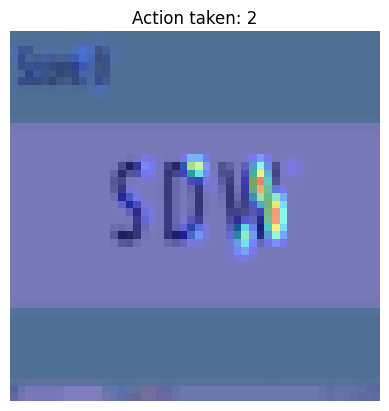

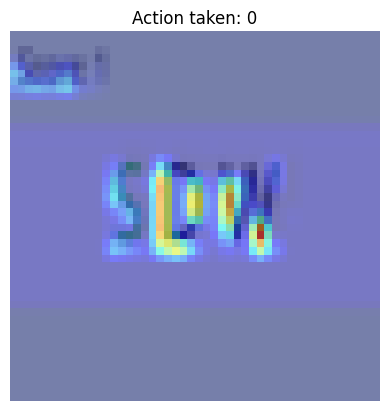

In [38]:
obs, _ = env.reset()
done = False
x = 0

while x < 3 and not done:
    x += 1
    time.sleep(0.5)

    grads.clear()
    activations.clear()

    # === Prepare input ===
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0).requires_grad_()  # Shape: (1, 3, 48, 48)

    # === Forward pass ===
    logits = model(obs_tensor)
    action = torch.argmax(logits, dim=1).item()

    # === Backward pass ===
    score = logits[0, action]
    model.zero_grad()
    score.backward()

    # === Grad-CAM ===
    grad = grads[0]  # (1, C, H, W)
    activation = activations[0]

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activation).sum(dim=1).squeeze()

    cam = F.relu(cam)
    cam -= cam.min()
    cam /= cam.max()
    cam = cam.cpu().numpy()
    cam = cv2.resize(cam, (48, 48))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)

    # === Handle RGB observation ===
    obs_np = obs.cpu().numpy() if torch.is_tensor(obs) else obs  # (3, 48, 48)
    obs_img = np.transpose(obs_np, (1, 2, 0))  # Convert to (48, 48, 3)
    obs_img = (obs_img * 255).clip(0, 255).astype(np.uint8)

    if obs_img.shape[:2] != heatmap.shape[:2]:
        obs_img = cv2.resize(obs_img, (heatmap.shape[1], heatmap.shape[0]))

    overlay = cv2.addWeighted(obs_img, 0.5, heatmap, 0.5, 0)

    # === Show image ===
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Action taken: {action}")
    plt.axis("off")
    plt.show()

    # === Step the environment ===
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

env.close()


# Quick Recap
We have a model which uses behvaiour cloning to achieve good results. The model can currently reach a score of 26, but the goal is to create a perfect model. This can be achieved in two ways:
### More Expert Data
This would require me to play the game more. But I don't want to do that. I am pretty sure I could create a perfect model with more expert data, but this is boring.
### Continue with RL
The model currently has a good base. It could be trained even further using Reinforcement Learning. This approach is also more interesting since I cannot fill in what will happen

In [3]:
import torch
import numpy as np
import pickle
import torch.optim as optim
import torch.nn as nn
from DQNCNN import DQNCNN
from WASDEnv import WinFormsGameEnv  # or your custom gym env
import time

# Load the pre-trained model if you have it
model = DQNCNN(action_size=4)
model.load_state_dict(torch.load("models/bc_model.pth"))

# Create environment
env = WinFormsGameEnv()

# Hyperparameters
batch_size = 64
learning_rate = 1e-3
epochs = 5000  # Number of episodes to train over

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(epochs):
    model.train()  # Set the model to training mode
    obs, _ = env.reset()
    done = False
    score = 0
    total_loss = 0

    # Collect training data (observations and actions)
    obs_list = []
    action_list = []

    while not done:
        # Preprocess observation: (84, 84) -> (1, 1, 84, 84)
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0).unsqueeze(0)  # Add batch and channel dims
        obs_tensor = obs_tensor.squeeze(1)

        # Get model prediction (action prediction based on observation)
        with torch.no_grad():
            logits = model(obs_tensor)
            action = torch.argmax(logits, dim=1).item()

        # Store observation and action for training
        obs_list.append(obs_tensor)
        action_list.append(action)

        # Take action in environment
        time.sleep(.005)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        score += 1

    # Now train the model on the data collected during the episode
    obs_tensor = torch.cat(obs_list)  # (N, 1, 84, 84)
    action_tensor = torch.LongTensor(action_list)  # (N, )

    # Zero gradients
    optimizer.zero_grad()

    # Forward pass
    logits = model(obs_tensor)

    # Calculate loss (cross-entropy between predicted and true actions)
    loss = criterion(logits, action_tensor)
    total_loss += loss.item()

    # Backward pass
    loss.backward()

    # Update model parameters
    optimizer.step()

    print(f"Epoch {epoch + 1}/{epochs} | Score: {score} | Loss: {total_loss:.4f}")

env.close()


C:\Users\Kaan\AppData\Local\Temp\ipykernel_10316\610308021.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/bc_model.pth"))


Epoch 1/5000 | Score: 5 | Loss: 0.1248
Epoch 2/5000 | Score: 6 | Loss: 0.1659
Epoch 3/5000 | Score: 2 | Loss: 0.0003
Epoch 4/5000 | Score: 1 | Loss: 0.2129
Epoch 5/5000 | Score: 2 | Loss: 0.0004
Epoch 6/5000 | Score: 1 | Loss: 0.0000
Epoch 7/5000 | Score: 3 | Loss: 0.2506
Epoch 8/5000 | Score: 1 | Loss: 0.0000
Epoch 9/5000 | Score: 1 | Loss: 0.0004
Epoch 10/5000 | Score: 1 | Loss: 0.0001
Epoch 11/5000 | Score: 2 | Loss: 0.0000
Epoch 12/5000 | Score: 2 | Loss: 0.1068
Epoch 13/5000 | Score: 3 | Loss: 0.1205
Epoch 14/5000 | Score: 1 | Loss: 0.0000
Epoch 15/5000 | Score: 1 | Loss: 0.0006
Epoch 16/5000 | Score: 4 | Loss: 0.0239
Epoch 17/5000 | Score: 2 | Loss: 0.0000
Epoch 18/5000 | Score: 2 | Loss: 0.0048
Epoch 19/5000 | Score: 2 | Loss: 0.3782
Epoch 20/5000 | Score: 2 | Loss: 0.0000
Epoch 21/5000 | Score: 1 | Loss: 0.1586
Epoch 22/5000 | Score: 1 | Loss: 0.0004
Epoch 23/5000 | Score: 3 | Loss: 0.0853
Epoch 24/5000 | Score: 2 | Loss: 0.0012
Epoch 25/5000 | Score: 1 | Loss: 0.2389
Epoch 26/

In [4]:
torch.save(model.state_dict(), "bc_model_5000.pth")

# Results
Reinforcement learning has made the model terrible. But Why?

In [8]:
bc_data = [15, 26, 35, 13, 26, 5, 23, 4, 32, 9, 19, 59, 25, 6, 22, 1, 20, 38, 14, 18, 12, 21, 1, 47, 35, 2, 29, 13, 5, 11, 5, 7, 51, 3, 30, 8, 38, 50, 27, 22, 4, 14, 11, 4, 3, 9, 5, 25, 15, 6, 19, 2, 11, 11, 38, 9, 9, 7, 8, 31, 16, 4, 22, 5, 24, 21, 19, 10, 1, 3, 41, 5, 34, 1, 2, 23, 4, 13, 20, 2, 9, 4, 1, 30, 73, 47, 3, 12, 61, 2, 2, 20, 11, 9, 7, 20, 6, 3, 9, 38]
bc_rl_5000_data = [2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2]
results = [bc_data, bc_rl_5000_data]
labels = ['BC Only', 'BC + 5000 RL']

C:\Users\Kaan\AppData\Local\Temp\ipykernel_10316\4176448943.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, patch_artist=True,


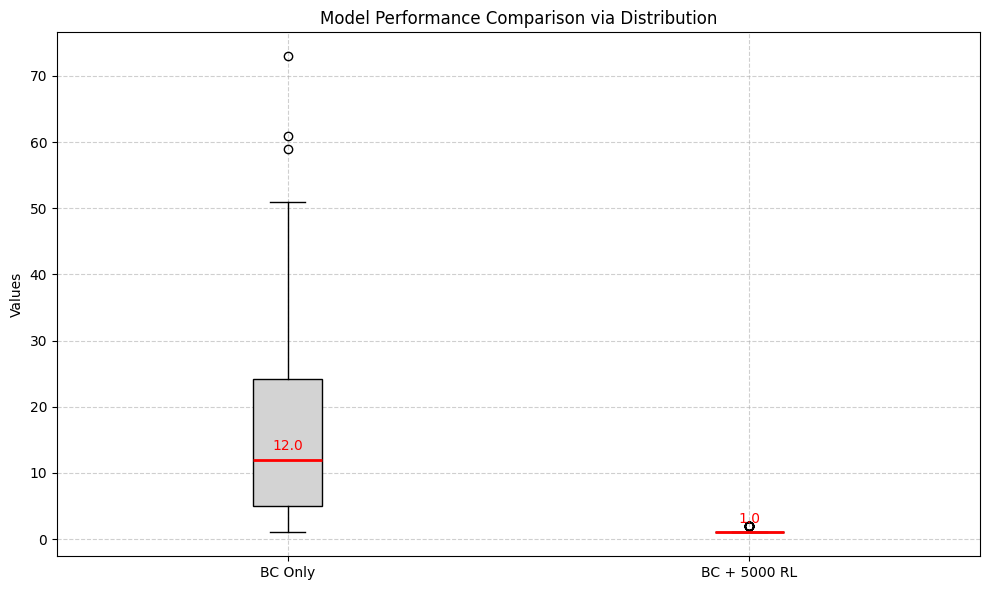

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Combine data
data = results
labels = labels

# Compute medians
medians = [np.median(d) for d in data]

# Create boxplot
plt.figure(figsize=(10, 6))
box = plt.boxplot(data, labels=labels, patch_artist=True,
                  boxprops=dict(facecolor="lightgray", color="black"),
                  medianprops=dict(color="red", linewidth=2))

# Annotate median values
for i, median in enumerate(medians):
    plt.text(i + 1, median + 1, f'{median:.1f}',  # add a little offset above the line
             ha='center', va='bottom', fontsize=10, color='red')

# Add title and labels
plt.ylabel('Values')
plt.title('Model Performance Comparison via Distribution')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Gradcam Check

In [10]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2

# Store gradients and activations
grads = []
activations = []

# Hook functions
def save_activation(module, input, output):
    activations.append(output.detach())

def save_gradient(module, grad_input, grad_output):
    grads.append(grad_output[0].detach())

# Register hooks on the last conv layer
target_layer = model.conv1
target_layer.register_forward_hook(save_activation)
target_layer.register_backward_hook(save_gradient)


C:\Users\Kaan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\nn\modules\module.py:1640: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


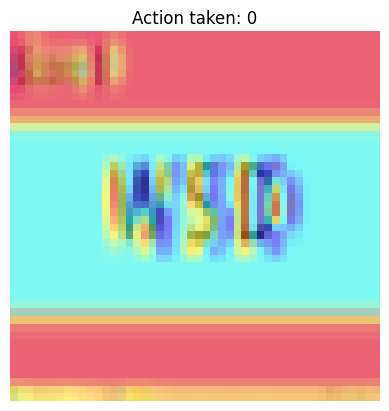

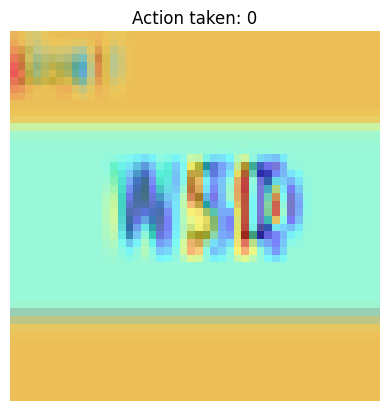

In [11]:
obs, _ = env.reset()
done = False
x = 0

while x < 3 and not done:
    x += 1
    time.sleep(0.5)

    grads.clear()
    activations.clear()

    # === Prepare input ===
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0).requires_grad_()  # Shape: (1, 3, 48, 48)

    # === Forward pass ===
    logits = model(obs_tensor)
    action = torch.argmax(logits, dim=1).item()

    # === Backward pass ===
    score = logits[0, action]
    model.zero_grad()
    score.backward()

    # === Grad-CAM ===
    grad = grads[0]  # (1, C, H, W)
    activation = activations[0]

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activation).sum(dim=1).squeeze()

    cam = F.relu(cam)
    cam -= cam.min()
    cam /= cam.max()
    cam = cam.cpu().numpy()
    cam = cv2.resize(cam, (48, 48))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)

    # === Handle RGB observation ===
    obs_np = obs.cpu().numpy() if torch.is_tensor(obs) else obs  # (3, 48, 48)
    obs_img = np.transpose(obs_np, (1, 2, 0))  # Convert to (48, 48, 3)
    obs_img = (obs_img * 255).clip(0, 255).astype(np.uint8)

    if obs_img.shape[:2] != heatmap.shape[:2]:
        obs_img = cv2.resize(obs_img, (heatmap.shape[1], heatmap.shape[0]))

    overlay = cv2.addWeighted(obs_img, 0.5, heatmap, 0.5, 0)

    # === Show image ===
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Action taken: {action}")
    plt.axis("off")
    plt.show()

    # === Step the environment ===
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

env.close()
